Final cumulative alpha from the noise test: 0.0492


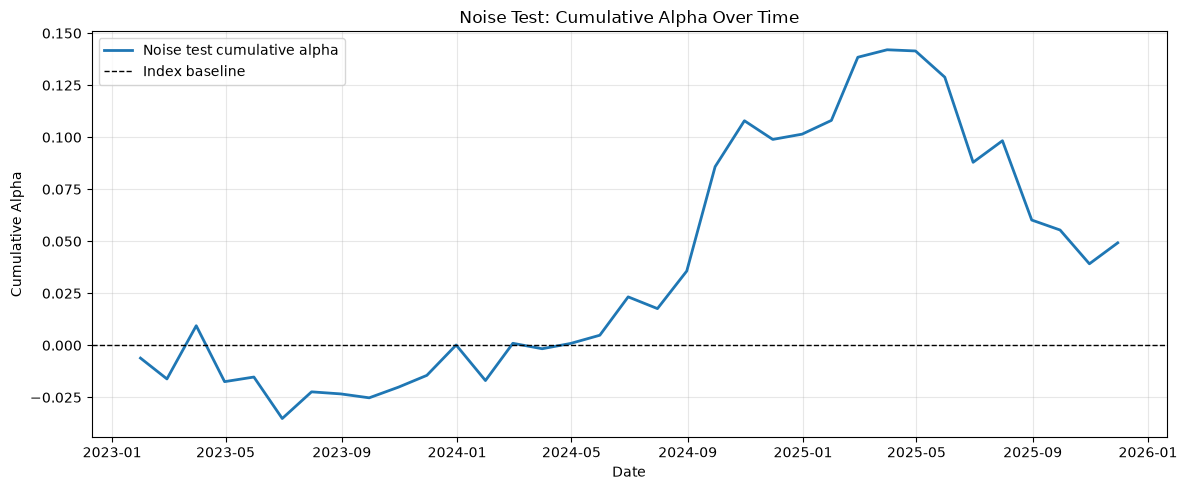

In [5]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the backtest dataset from disk.
df = pd.read_excel("../data/omxs30_modell_gissningar.xlsx")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

# Create a noise version of the predictions.
df_noise = df.copy()
np.random.seed(42)
df_noise["XGB_Predicted_Return"] = np.random.randn(len(df_noise))

# Apply the same monthly top-10 selection logic as in the main backtest.
noise_rows = []
for date, group in df_noise.groupby("Date"):
    top_10 = group.sort_values("XGB_Predicted_Return", ascending=False).head(10)
    monthly_alpha = top_10["Target_Next_Month_Relative_Return"].mean()
    noise_rows.append({
        "Date": date,
        "Portfolio_Alpha": monthly_alpha,
        "Num_Selected": len(top_10),
    })

df_noise_backtest = pd.DataFrame(noise_rows).sort_values("Date").reset_index(drop=True)
df_noise_backtest["Cumulative_Alpha"] = (1 + df_noise_backtest["Portfolio_Alpha"]).cumprod() - 1

final_cumulative_alpha = df_noise_backtest["Cumulative_Alpha"].iloc[-1]
print(f"Final cumulative alpha from the noise test: {final_cumulative_alpha:.4f}")

# Visualize the cumulative alpha over time.
plt.figure(figsize=(12, 5))
plt.plot(df_noise_backtest["Date"], df_noise_backtest["Cumulative_Alpha"], linewidth=2, label="Noise test cumulative alpha")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Index baseline")
plt.title("Noise Test: Cumulative Alpha Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../images/noise_test_chart.png', bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd

# 1. Ladda in gissningarna med rätt relativ sökväg
df_predictions = pd.read_excel("../data/omxs30_modell_gissningar.xlsx")

# 2. Välj en aktie att testa (t.ex. VOLV_B, INVE_B eller AZN)
test_ticker = "VOLV-B.ST" 

# 3. Hämta raden för beslutsdatumet
df_predictions['Date'] = pd.to_datetime(df_predictions['Date']).dt.strftime('%Y-%m-%d')
df_check = df_predictions[(df_predictions['Date'] == '2023-04-30') & (df_predictions['Ticker'] == test_ticker)]

print("--- VERIFIERING AV LOOK-AHEAD BIAS ---")
if not df_check.empty:
    print(f"Aktie: {test_ticker}")
    print(f"Beslutsdatum: {df_check['Date'].values[0]}")
    print(f"Modellens gissade avkastning: {df_check['XGB_Predicted_Return'].values[0]:.4f}")
    print(f"Faktiskt utfall nästa månad (Target): {df_check['Target_Next_Month_Relative_Return'].values[0]:.4f}")
else:
    print(f"Hittade inte '{test_ticker}' för datumet 2023-04-30. Testa att byta test_ticker till en annan aktie som finns i din Excel-fil.")

--- VERIFIERING AV LOOK-AHEAD BIAS ---
Aktie: VOLV-B.ST
Beslutsdatum: 2023-04-30
Modellens gissade avkastning: 0.0016
Faktiskt utfall nästa månad (Target): -0.0344
